In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

In [3]:
X_train.shape

(60000, 28, 28)

In [4]:
def imshow(X,y):
    if X.lower() == 'train':
        print(f"{X} : {y_train[y]}")
        plt.imshow(X_train[y])
        plt.show()
    elif X.lower() =='test':
        print(f"{X} : {y_test[y]}")
        plt.imshow(X_test[y])
        plt.show()        

In [5]:
X_train = X_train/255
X_test = X_test/255

train : 5


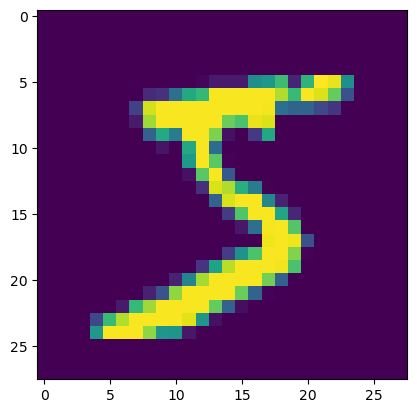

In [6]:
imshow('train',0)

In [7]:
X_train_flat = X_train.reshape(len(X_train),28*28)
X_test_flat = X_test.reshape(len(X_test),28*28)
X_train_flat

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [41]:
model = keras.Sequential([
    keras.layers.Dense(10,input_shape=(784,),activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(X_train_flat,y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8180 - loss: 0.7105
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9152 - loss: 0.3087
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9201 - loss: 0.2876
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9223 - loss: 0.2746
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9250 - loss: 0.2692
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9287 - loss: 0.2560
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9264 - loss: 0.2648
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9293 - loss: 0.2528
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9299 - loss: 0.2505
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9298 - loss: 0.2539


In [42]:
model.evaluate(X_test_flat,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9171 - loss: 0.2977


[0.2634068727493286, 0.9283000230789185]

In [50]:
y_pred = model.predict(X_test_flat)

y_pred_labels = [np.argmax(i) for i in y_pred]


cm = tf.math.confusion_matrix(labels = y_test, predictions = y_pred_labels)
cm

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 956,    0,    2,    2,    1,    5,   10,    3,    1,    0],
       [   0, 1114,    4,    2,    0,    1,    4,    2,    8,    0],
       [   4,    8,  939,   14,    9,    3,   12,    8,   32,    3],
       [   1,    0,   24,  925,    2,   19,    3,   10,   21,    5],
       [   1,    1,    4,    2,  926,    0,   10,    4,    8,   26],
       [   8,    3,    2,   37,   11,  770,   19,    7,   30,    5],
       [   7,    3,    8,    1,    7,    8,  922,    1,    1,    0],
       [   1,    6,   27,    2,    9,    1,    0,  953,    2,   27],
       [   7,    9,    7,   22,    9,   24,   11,   11,  864,   10],
       [  11,    8,    1,    9,   33,    6,    0,   21,    6,  914]])>

In [40]:
model1 = keras.Sequential([
    keras.layers.Dense(100,input_shape=(784,),activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model1.fit(X_train_flat,y_train,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8740 - loss: 0.4424
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9610 - loss: 0.1305
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9747 - loss: 0.0849
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9810 - loss: 0.0611
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9849 - loss: 0.0492


In [52]:
model1.evaluate(X_test_flat,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9709 - loss: 0.0955


[0.08434947580099106, 0.9746999740600586]

In [51]:
y_pred1 = model1.predict(X_test_flat)

y_pred_labels1 = [np.argmax(i) for i in y_pred1]


cm1 = tf.math.confusion_matrix(labels = y_test, predictions = y_pred_labels1)
cm1

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 966,    0,    1,    0,    4,    1,    3,    1,    2,    2],
       [   0, 1106,    3,    1,    1,    1,    4,    1,   16,    2],
       [   5,    0,  986,    7,    4,    0,    2,    9,   17,    2],
       [   0,    0,    2,  981,    1,    6,    0,    7,    5,    8],
       [   2,    0,    0,    1,  959,    0,    5,    1,    1,   13],
       [   2,    0,    0,    5,    1,  875,    4,    1,    3,    1],
       [   6,    1,    0,    1,    3,    7,  937,    0,    3,    0],
       [   1,    2,    5,    1,    0,    0,    0, 1004,    3,   12],
       [   4,    0,    1,    4,    3,    5,    1,    5,  943,    8],
       [   2,    1,    0,    2,    6,    2,    0,    6,    0,  990]])>